人机交互
***
- 基本运用：等待用户输入
- 基本运用：审查工具调用
- 基本使用：编辑图的状态

等待用户输入或介入
***
在节点与节点之间增加人类的反馈节点

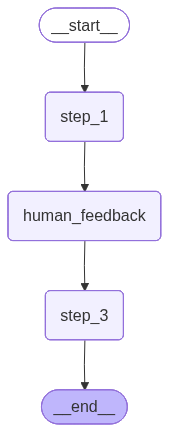

In [3]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import display, Image

class State(TypedDict):
    input: str
    user_feedback: str

def step_1(state):
    print('---Step 1 ---')
    pass  

def human_feedback(state):
    print("---Human_feedback")
    feedback = interrupt('please provide feedback')
    return {"user_feedback": feedback}

def step_3(state):
    print('---Step 3 ---')
    pass

builder = StateGraph(State)
builder.add_node('step_1', step_1)
builder.add_node('human_feedback', human_feedback)
builder.add_node('step_3', step_3)
builder.add_edge(START, 'step_1')
builder.add_edge('step_1', 'human_feedback')
builder.add_edge('human_feedback', 'step_3')
builder.add_edge('step_3', END)

# set up memory
memory = MemorySaver()

# Add
graph = builder.compile(checkpointer=memory)

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [4]:
# Input
initial_input = {"input": "你好"}

# config
config = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, config, stream_mode="updates"):
    print(event)
    print("\n")

---Step 1 ---
{'step_1': None}


---Human_feedback
{'__interrupt__': (Interrupt(value='please provide feedback', id='f6e30c013e2bc027fe20d369a715fac4'),)}




Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


添加人类反馈

In [5]:
for event in graph.stream(
    Command(resume="go to step3!"), config, stream_mode="updates"
):
    print(event)
    print("\n")

---Human_feedback
{'human_feedback': {'user_feedback': 'go to step3!'}}


---Step 3 ---
{'step_3': None}




Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


在智能体中引入人工介入的环节

In [ ]:
from langgraph.graph import MessageState, START

from langgraph.tools import tool
from langgraph.prebuilt import ToolNode 

@tool
def search(query: str):
    """调用此函数来浏览网络"""
    # 这只是一个实际的点位符
    # 不要让大语言模型知道这点哦
    return f"我查询了：{query}。结果：北京天气晴朗，温度25度。"

tools = [search]
tool_node = ToolNode(tools)

# 设置模型
from langchain_deepseek import ChatDeepSeek
import os

model = ChatDeepSeek(
    model="Pro/deepseek-ai/DeepSeek-V3",
    temperature=0
)


from pydantic import BaseModel

# 我们将“绑定”所有工具到模型
# 我们有上面的实际工具，但我们还需要一个模拟工具来询问人类
# 由于“bind_tools”接受工具也接受工具定义
# 我们可以为“ask_human”定义一个工具定义
class AskHuman(BaseModel):
    """向人类提问"""
    question: str

model = model.bind_tools(tools+[AskHuman])

# 定义节点和条件边
# 定义确定是否继续的函数
def should_continue(state):
    messages = state["messages"]
    last_message = messages[-1]
    # 如果没有函数调用，则结束
    if not last_message.tool_calls:
        return END
    # 如果工具调用是人类，我们返回该节点
    # 你也可以在这里添加逻辑， 让某些系统知道有需要人类输入
    elif last_message.tool_calls[0]["name"] == "AskHuman":
        return "ask_human"
    # 否则如果有，我们继续
    else:
        return "action"

# 定义调用模型的节点
def call_model(state):
    messages = state["messages"]
    response = model.invoke(messages)
    # 我们返回一个列表，因为这将被添加到现有列表中
    return {"messages": [response]}    

# 定义一个假节点来询问人类
def ask_human(state):
    tool_call_id = state["messages"][-1].tool_calls[0]["id"]
    ask = AskHuman.model.validate(state["messages"][-1].tool_calls[0]['args'])
    location = interrupt(ask.question)
    tool_message = [{"tool_call_id": tool_call_id, "type": "tool", "content": location}]
    return {"messages": tool_message}

# 构建图
from langgraph.graph import StateGraph, END

# 定义一个图
workflow = StateGraph(MessageState)

# 定义循环的三个节点
workflow.add_node('agent', call_model)
workflow.add_node('action', tool_node)
workflow.add_node('ask_human', ask_human)

# 将入口点设置为'agent'
# 这意味着这个节点是第一个被调用的
workflow.add_edge(START, "agent")

# 现在添加一个条件边
workflow.add_conditional_edges(
  "agent",
  should_continue
)

# 我们从tools到agent添加一条普通边
# 这意味着在调用tools之后，下一步调用agent节点
workflow.add_edge("action", "agent")

# 我们在获得人类响应后，我们回到代理
workflow.add_edge("ask_human", "agent")

# 设置内存
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

app = workflow.compile(checkpointer=memory)

display(Image(app.get_graph().draw_mermaid_png()))

调用

In [ ]:
config = {"configurable": {"thread_id": "2"}}
for event in app.stream(
    {
       "messages": [
            (
                "user",
                "询问用户他们在哪里，然后查询那里的天气"
            )
        ]
    },
    config,
    stream_mode="values"
):
    event["messages"][-1].pretty_print()

In [ ]:
for event in app.stream(Command(resume="北京"), config, stream_mode="values"):
    event["messages"][-1].pretty_print()

人机交互-对图的状态进行编辑
***
使用断点对节点间的消息进行人工干预

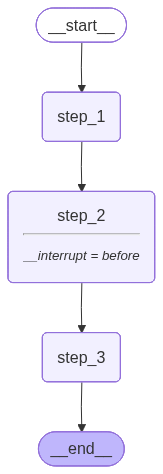

In [7]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import display

class State(TypedDict):
    input: str

def step_1(state):
    print("---Step 1---")
    pass

def step_2(state):
    print("---Step 2---")
    pass

def step_3(state):
    print("---Step 3---")
    pass

builder = StateGraph(State)
builder.add_node('step_1', step_1)
builder.add_node('step_2', step_2)
builder.add_node('step_3', step_3)
builder.add_edge(START, 'step_1')
builder.add_edge('step_1', 'step_2')
builder.add_edge('step_2', 'step_3')
builder.add_edge('step_3', END)

# Set up memory
memory = MemorySaver()

# Add 注意interrupt_before
graph = builder.compile(checkpointer=memory, interrupt_before=['step_2'])

# View 
display(Image(graph.get_graph().draw_mermaid_png()))


In [8]:
# Input
initial_input = {"input": "你好"}

# Thread
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode="values"):
    print(event)

{'input': '你好'}
---Step 1---


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


此时可以人工介入

In [9]:
graph.update_state(thread, {"input": "你好 lgoto.ai!"})
print("--\n--\nUpdated state!")
print(graph.get_state(thread).values)

--
--
Updated state!
{'input': '你好 lgoto.ai!'}


In [10]:
# 继续执行
for event in graph.stream(None, thread, stream_mode="values"):
    print(event)

{'input': '你好 lgoto.ai!'}
---Step 2---
---Step 3---


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
